# Fig 5 — Antenna patterns

Three Mollweide projections of the per-pulsar sky response for a pulsar at $\hat p=(0,0,1)$: the true PTA antenna pattern at $f=1/T_{\rm obs}$, and two synthetic top-hat patches ($\theta_0=30^\circ,\,15^\circ$).

These responses underpin the mechanism shown in Fig 4: the true PTA pattern is broad, so each pulsar averages the signal over a large fraction of the sky and the central limit theorem Gaussianizes the timing residuals; the $30^\circ$ and $15^\circ$ patches are progressively narrower, suppressing that averaging so the source amplitude statistics survive in the whitened data.

## How to use this notebook
If you have downloaded this notebook from the repo set `REGENERATE_DATA = True` to recompute the data. It will be saved as `data/fig5_antenna_patterns.npz`.

If you want to save the plot (it is saved under `plots/fig5_antenna_pattern.pdf`), set `SAVE_PLOT` to True.

In [1]:
REGENERATE_DATA = False
SAVE_PLOT = True

In [2]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

import jax
jax.config.update('jax_enable_x64', True)

from fastPTA.data import datastream as gds
from fastPTA import utils as ut

from helpers.pta_helpers import set_paper_rcparams

DATA_PATH = Path('data') / 'fig5_antenna_patterns.npz'
PLOT_PATH = Path('plots') / 'fig5_antenna_pattern.pdf'
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

NSIDE = 256
F_HZ = 1.0 / (16.03 * 365.25 * 86400.0) / 20.0  # matches the paper figure

## Compute or load the three maps

In [3]:
def _build_patch_map(k_vec, p_hat, angular_radius_deg):
    ang = np.arccos(np.clip(k_vec @ p_hat, -1.0, 1.0))
    return (ang <= np.deg2rad(angular_radius_deg)).astype(float)


def compute_maps(nside=NSIDE, f_hz=F_HZ):
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_k, phi_k = hp.pix2ang(nside, pix)
    k_vec = np.column_stack(hp.pix2vec(nside, pix))

    p_hat = np.array([0.0, 0.0, 1.0])
    p_vec = p_hat[None, :]
    distances = np.array([1_000.0]) * ut.parsec
    fcenter = np.array([f_hz])
    r_p, r_c = gds.get_R_pc(fcenter, distances, p_vec, theta_k, phi_k)
    real_map = np.sqrt(
        np.abs(np.array(r_p[0, :, 0])) ** 2
        + np.abs(np.array(r_c[0, :, 0])) ** 2
    )
    real_map /= real_map.max()
    patch30_map = _build_patch_map(k_vec, p_hat, 30.0)
    patch15_map = _build_patch_map(k_vec, p_hat, 15.0)
    return real_map, patch30_map, patch15_map

In [4]:
if REGENERATE_DATA or not DATA_PATH.exists():
    print(f'Computing maps at Nside={NSIDE} ...')
    real_map, patch30_map, patch15_map = compute_maps()
    np.savez(DATA_PATH,
             real_map=real_map,
             patch30_map=patch30_map,
             patch15_map=patch15_map)
    print(f'Saved {DATA_PATH}')
else:
    data = np.load(DATA_PATH)
    real_map = data['real_map']
    patch30_map = data['patch30_map']
    patch15_map = data['patch15_map']
    print(f'Loaded {DATA_PATH} (npix = {real_map.size})')

Loaded data/fig5_antenna_patterns.npz (npix = 786432)


## Plot

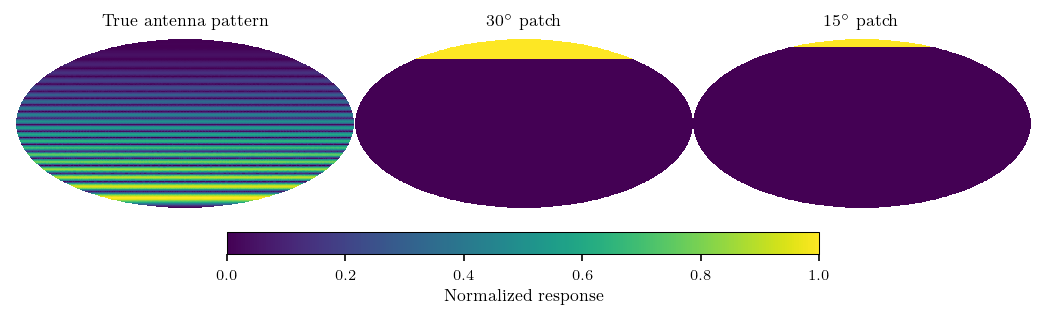

Saved plots/fig5_antenna_pattern.pdf


In [5]:
use_tex, _, TEXT_W = set_paper_rcparams()

maps = [real_map, patch30_map, patch15_map]
titles = ['True antenna pattern', r'$30^\circ$ patch', r'$15^\circ$ patch']
subs = [231, 233, 235]

fig = plt.figure(figsize=(TEXT_W, 4.35))
for hp_map, title, sub in zip(maps, titles, subs):
    hp.mollview(
        hp_map,
        fig=fig.number,
        sub=sub,
        rot=(0.0, 0.0, 0.0),
        title=title,
        cmap='viridis',
        min=0.0,
        max=1.0,
        cbar=False,
        notext=True,
        hold=False,
        margins=(0.02, 0.05, 0.02, 0.04),
    )

map_positions = [
    [0.02, 0.35, 0.32, 0.40],
    [0.34, 0.35, 0.32, 0.40],
    [0.66, 0.35, 0.32, 0.40],
]
for ax, pos in zip(fig.axes[:3], map_positions):
    ax.set_position(pos)

sm = ScalarMappable(norm=Normalize(0.0, 1.0), cmap='viridis')
sm.set_array([])
cax = fig.add_axes([0.22, 0.35, 0.56, 0.035])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Normalized response')

plt.show()

if SAVE_PLOT:
    fig.savefig(PLOT_PATH)
    print(f'Saved {PLOT_PATH}')